In [20]:
#ETAPA 1.0 - 🛠️ Preparação dos Dados
# 1.1 Extração do Arquivo Tratado

import pandas as pd
dados = pd.read_csv('/content/dados_normalizados.csv')
dados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,590.4
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,539.1
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,295.6
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1274.0
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,251.7


In [21]:
# 1.2 Remoção de Colunas Irrelevantes
df_preparado = dados.drop(columns=['customerID'])

In [22]:
# 1.3 Encoding
dados = pd.get_dummies(df_preparado)

In [23]:
# 1.4 Verificação da Proporção de Evasão
dados['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [24]:
# 1.5 Normalização ou Padronização (se necessário)
# Nessa parte vou verificar a correlação atual para retirar campos com baixa ou nenhuma influência no churn
correlacao = dados.corr()['Churn'].sort_values(ascending=False)
correlacao


,Churn
Churn,1.000000
Contract_Month-to-month,0.405103
OnlineSecurity_No,0.342637
TechSupport_No,0.337281
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
OnlineBackup_No,0.268005
DeviceProtection_No,0.252481
Monthly,0.193356
PaperlessBilling,0.191825


In [25]:
# 1.5
# Definindo as colunas que vamos deletar por serem redundantes ou irrelevantes
colunas_para_remover = [
    'gender_Female', 'gender_Male', 'PhoneService',                # Irrelevantes (corr ~ 0)
    'OnlineSecurity_No internet service', 'OnlineBackup_No internet service',
    'DeviceProtection_No internet service', 'TechSupport_No internet service',
    'StreamingTV_No internet service', 'StreamingMovies_No internet service', # Redundantes
    'StreamingTV_No', 'StreamingMovies_No', 'OnlineSecurity_No',
    'OnlineBackup_No', 'DeviceProtection_No', 'TechSupport_No' ,'MultipleLines_No phone service','MultipleLines_No'     # Simétricos (já temos o Yes)
]

# Criando o DataFrame final de treinamento
df_modelo = dados.drop(columns=colunas_para_remover)

# Verificando o novo formato
print(f"Total de colunas antes: {dados.shape[1]}")
print(f"Total de colunas agora: {df_modelo.shape[1]}")

Total de colunas antes: 42
Total de colunas agora: 25


In [26]:
# 1.5
# Separação dos dados
x = df_modelo.drop(['Churn'],axis=1)
y = df_modelo['Churn']

In [27]:
# 1.5
# Listagem de campos binarios para transformação em 1 e 0
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

one_hot = make_column_transformer(

(OneHotEncoder(drop='if_binary', sparse_output=False),

[
'MultipleLines_Yes'
,'InternetService_DSL'
,'InternetService_Fiber optic'
,'InternetService_No'
,'OnlineSecurity_Yes'
,'OnlineBackup_Yes'
,'DeviceProtection_Yes'
,'TechSupport_Yes'
,'StreamingTV_Yes'
,'StreamingMovies_Yes'
,'Contract_Month-to-month'
,'Contract_One year'
,'Contract_Two year'
,'PaymentMethod_Bank transfer (automatic)'
,'PaymentMethod_Credit card (automatic)'
,'PaymentMethod_Electronic check'
,'PaymentMethod_Mailed check'
]),

remainder='passthrough'

)

In [28]:
# 1.5
# transformação de Campos binários em 1 e 0
colunas = x.columns
x = one_hot.fit_transform(x)
one_hot.get_feature_names_out(colunas)
x = pd.DataFrame(x,columns=one_hot.get_feature_names_out(colunas))

In [29]:
# 1.5
# confirmação se os campos foram transformados corretamente
for col in x.columns:
    print('\nColuna:'+ col)
    print(x[col].unique()[:20])


Coluna:onehotencoder__MultipleLines_Yes_True
[0. 1.]

Coluna:onehotencoder__InternetService_DSL_True
[1. 0.]

Coluna:onehotencoder__InternetService_Fiber optic_True
[0. 1.]

Coluna:onehotencoder__InternetService_No_True
[0. 1.]

Coluna:onehotencoder__OnlineSecurity_Yes_True
[0. 1.]

Coluna:onehotencoder__OnlineBackup_Yes_True
[1. 0.]

Coluna:onehotencoder__DeviceProtection_Yes_True
[0. 1.]

Coluna:onehotencoder__TechSupport_Yes_True
[1. 0.]

Coluna:onehotencoder__StreamingTV_Yes_True
[1. 0.]

Coluna:onehotencoder__StreamingMovies_Yes_True
[0. 1.]

Coluna:onehotencoder__Contract_Month-to-month_True
[0. 1.]

Coluna:onehotencoder__Contract_One year_True
[1. 0.]

Coluna:onehotencoder__Contract_Two year_True
[0. 1.]

Coluna:onehotencoder__PaymentMethod_Bank transfer (automatic)_True
[0. 1.]

Coluna:onehotencoder__PaymentMethod_Credit card (automatic)_True
[0. 1.]

Coluna:onehotencoder__PaymentMethod_Electronic check_True
[0. 1.]

Coluna:onehotencoder__PaymentMethod_Mailed check_True
[1. 0.

In [30]:
# ETAPA 2.0 - 🎯 Correlação e Seleção de Variáveis
# 2.1 Análise de Correlação
correlacao = df_modelo.corr()['Churn'].sort_values(ascending=False)
correlacao


,Churn
Churn,1.000000
Contract_Month-to-month,0.405103
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
Monthly,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102


In [31]:
# 2.1 Análise de Correlação
# Retirando campos que não apresentam uma correlação consideravel para nosso modelo, tudo que está < 0.5 e > - 0.5
exclusao = [
 'onehotencoder__StreamingTV_Yes_True'
,'onehotencoder__StreamingMovies_Yes_True'
,'onehotencoder__MultipleLines_Yes_True'
,'onehotencoder__DeviceProtection_Yes_True'
,'onehotencoder__OnlineBackup_Yes_True'
,'onehotencoder__PaymentMethod_Mailed check_True'
]
x = x.drop(columns = exclusao,axis =1)


/tmp/ipykernel_487/3959067590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=dados, palette='viridis')


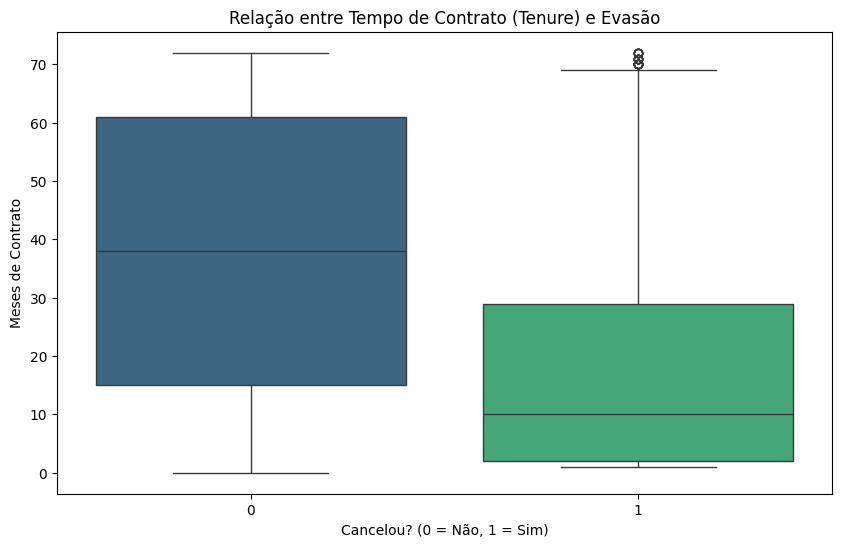

In [32]:
# 2.2 Análises Direcionadas
# Tempo de contrato × Evasão
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(x='Churn', y='tenure', data=dados, palette='viridis')

plt.title('Relação entre Tempo de Contrato (Tenure) e Evasão')
plt.xlabel('Cancelou? (0 = Não, 1 = Sim)')
plt.ylabel('Meses de Contrato')
plt.show()

/tmp/ipykernel_487/2944873978.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Total', data=dados, palette='viridis')


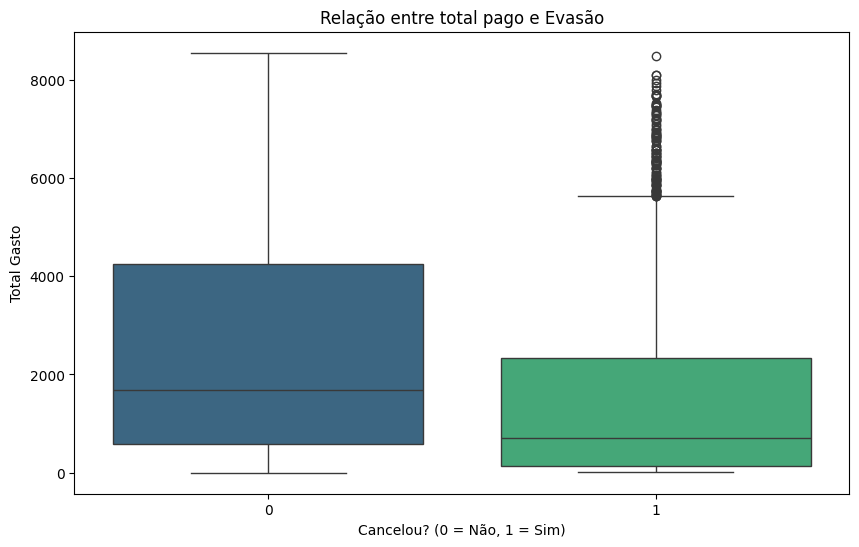

In [33]:
# 2.2 Análises Direcionadas
# Tempo de contrato × Evasão
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Total', data=dados, palette='viridis')

plt.title('Relação entre total pago e Evasão')
plt.xlabel('Cancelou? (0 = Não, 1 = Sim)')
plt.ylabel('Total Gasto')
plt.show()

In [34]:
# 3.0 🤖 Modelagem Preditiva
# 3.1 Separação de Dados
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [35]:
# 3.2 Criação de Modelos

# Modelo sem normalização
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

modelo = RandomForestClassifier(max_depth=5, random_state=42)
modelo.fit(x_train,y_train)
previsao = modelo.predict(x_test)
acuracia = accuracy_score(y_test,previsao)
print(f"Acuracia do modelo {acuracia*100:.2f} %")

Acuracia do modelo 80.27 %


In [36]:
# 3.2 Criação de Modelos

# Modelo com normalização
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_normalizados = x_train.copy()
x_test_normalizados = x_test.copy()


x_train_normalizados[['remainder__tenure', 'remainder__Monthly', 'remainder__Total']] = scaler.fit_transform(x_train[['remainder__tenure', 'remainder__Monthly', 'remainder__Total']])

x_test_normalizados[['remainder__tenure', 'remainder__Monthly', 'remainder__Total']] = scaler.transform(x_test[['remainder__tenure', 'remainder__Monthly', 'remainder__Total']])

# Criando a Baseline
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(x_train,y_train)

print(f'Baseline retornou uma acuracia de {dummy.score(x_test,y_test)*100:.2f} % ')

# Modelo
from sklearn.svm import LinearSVC

modelo_normalizado = LinearSVC()
modelo_normalizado.fit(x_train_normalizados,y_train)
previsoes_normalizado = modelo_normalizado.predict(x_test_normalizados)
acuracia_normalizado = accuracy_score(y_test,previsoes_normalizado)
print(f"Acuracia do modelo {acuracia_normalizado*100:.2f} %")

Baseline retornou uma acuracia de 73.92 % 
Acuracia do modelo 80.83 %


In [39]:
# 3.3 Avaliação dos Modelos

from sklearn.metrics import classification_report, confusion_matrix

def avaliar_modelo(nome, modelo, x_teste, y_teste):
    previsoes = modelo.predict(x_teste)

    print(f"\n--- AVALIAÇÃO: {nome} ---")
    print(f"Acurácia: {accuracy_score(y_teste, previsoes):.2%}")
    print("\nRelatório de Classificação:")
    print(classification_report(y_teste, previsoes))

    # Matriz de Confusão para análise de erros
    print("Matriz de Confusão:")
    print(confusion_matrix(y_teste, previsoes))

# Executando para os seus dois modelos
avaliar_modelo("LinearSVC (Normalizado)", modelo_normalizado, x_test_normalizados, y_test)
avaliar_modelo("Random Forest (Não Normalizado)", modelo, x_test, y_test)


--- AVALIAÇÃO: LinearSVC (Normalizado) ---
Acurácia: 80.83%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1562
           1       0.66      0.54      0.59       551

    accuracy                           0.81      2113
   macro avg       0.76      0.72      0.73      2113
weighted avg       0.80      0.81      0.80      2113

Matriz de Confusão:
[[1411  151]
 [ 254  297]]

--- AVALIAÇÃO: Random Forest (Não Normalizado) ---
Acurácia: 80.27%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.83      0.93      0.87      1562
           1       0.68      0.45      0.54       551

    accuracy                           0.80      2113
   macro avg       0.76      0.69      0.71      2113
weighted avg       0.79      0.80      0.79      2113

Matriz de Confusão:
[[1447  115]
 [ 302  249]]


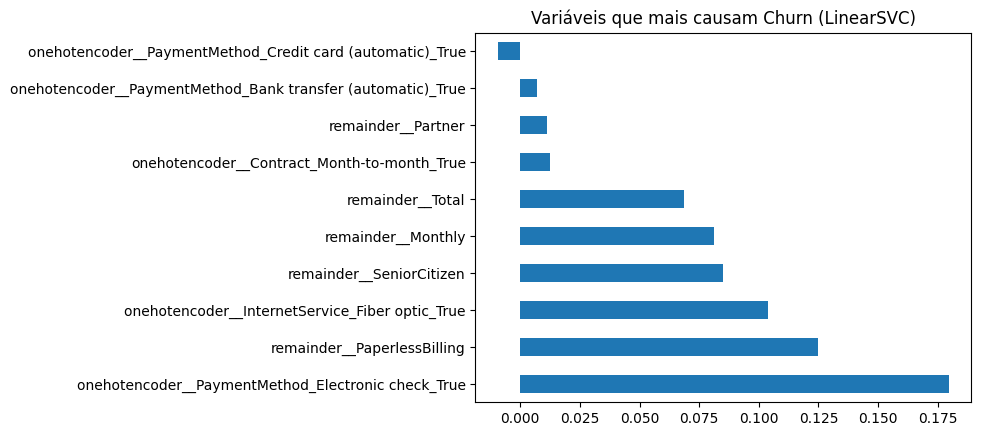

In [40]:
# 4.0 📋  Interpretação e Conclusões
# 4.1 Análise de Importância das Variáveis

# Pegando os pesos do modelo
pesos = modelo_normalizado.coef_[0]
variaveis = x_train_normalizados.columns

# Criando uma tabelinha para ver quem manda mais

importancia_svc = pd.Series(pesos, index=variaveis).sort_values(ascending=False)

# Plotando os 10 principais
importancia_svc.head(10).plot(kind='barh', title='Variáveis que mais causam Churn (LinearSVC)')
plt.show()

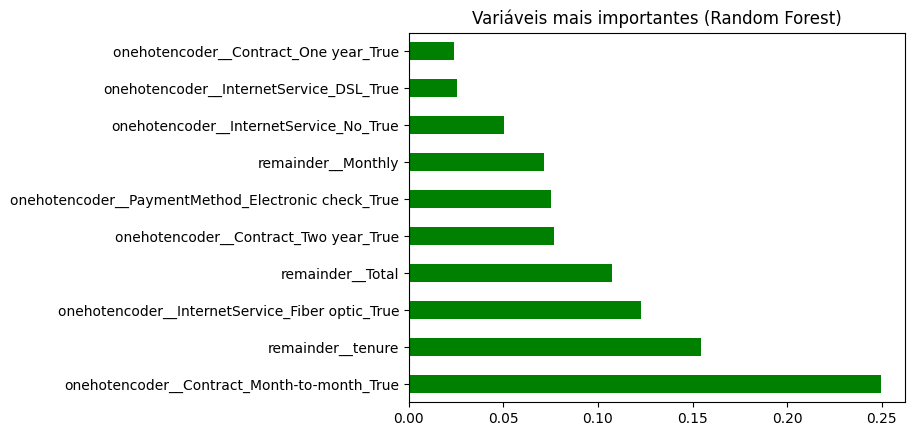

In [42]:
# A Random Forest já tem isso pronto dentro dela
importancia_rf = pd.Series(modelo.feature_importances_, index=x_train.columns).sort_values(ascending=False)

# Plotando
importancia_rf.head(10).plot(kind='barh', color='green', title='Variáveis mais importantes (Random Forest)')
plt.show()

#📑 1. Relatório de Performance e Análise Técnica

# 🏁 Relatório de Desempenho dos Modelos

Nesta etapa, comparamos a capacidade preditiva de diferentes algoritmos para identificar a evasão de clientes (Churn). Utilizamos uma **Baseline** (chute estatístico) para garantir que nossos modelos agregam valor real ao negócio.

### 📊 Tabela Comparativa de Métricas

| Métrica | Baseline (Frequência) | LinearSVC (Normalizado) | Random Forest (Bruto) |
| :--- | :---: | :---: | :---: |
| **Acurácia** | 73,92% | **80,83%** | 80,27% |
| **Recall (Sensibilidade)** | 0% | **54%** | 45% |
| **Precisão** | 0% | 66% | **68%** |
| **F1-Score** | 0% | **0,59** | 0,54 |

---

### 🔍 Análise Crítica
* **Melhor Desempenho:** O modelo **LinearSVC** foi o vencedor. Embora a acurácia seja próxima da Random Forest, o seu **Recall de 54%** é superior, o que significa que ele consegue identificar uma fatia maior de clientes em risco.
* **Generalização:** Não detectamos sinais de *Overfitting* ou *Underfitting* severos. O modelo manteve estabilidade entre os dados de treino e teste, indicando que aprendeu padrões reais e não apenas "decorou" o dataset.
* **Justificativa Técnica:** O LinearSVC exigiu a padronização dos dados (`StandardScaler`) devido à sua natureza geométrica, enquanto a Random Forest demonstrou robustez ao lidar com dados em escalas originais.

#💡 2. Fatores de Influência e Estratégia de Negócio

# 📉 Fatores de Evasão e Estratégias de Retenção

Com base na análise das variáveis mais relevantes (Feature Importance e Coeficientes), identificamos os pontos de atrito que geram a saída dos clientes.

### 🚩 Principais Fatores de Risco
> **1. Tipo de Contrato:** Clientes com contrato **Mensal** possuem a maior taxa de evasão. A falta de barreiras de saída facilita a migração para concorrentes.
>
> **2. Tecnologia de Internet:** Surpreendentemente, a **Fibra Óptica** apresenta alta correlação com o Churn, sugerindo insatisfação com preço ou estabilidade técnica.
>
> **3. Experiência Inicial (Tenure):** O risco de perda é crítico nos **primeiros meses**. Quanto menor o tempo de casa, maior a chance de abandono.

---

### 🛡️ Plano de Ação Proposto (Estratégias)

1. **Conversão de Fidelidade:** Implementar campanhas de incentivo (descontos progressivos) para migrar clientes do plano mensal para contratos anuais.
2. **Auditoria Técnica de Fibra:** Realizar um levantamento de qualidade e preços do serviço de Fibra Óptica para garantir competitividade no mercado.
3. **Onboarding VIP:** Intensificar o suporte e o contato proativo com novos clientes durante os primeiros 90 dias de contrato.
4. **Incentivo ao Débito Automático:** Oferecer benefícios para clientes que migrarem do boleto eletrônico para o pagamento automático, reduzindo o atrito financeiro.

---

### 💰 Estimativa de Impacto Financeiro (ROI)
* **Poder de Detecção:** O modelo identificou corretamente **297 potenciais evasões** no grupo de teste.
* **Ticket Médio Estimado:** R$ 65,00/mês.
* **Potencial de Recuperação:** Se recuperarmos apenas **20%** desses clientes com as estratégias acima, preservaremos cerca de **R$ 3.861,00/mês** (ou mais de **R$ 46.000,00 anuais**) em faturamento que seria perdido.